# Single Source Sub-Pixel Dithered Mosaic

This notebook demonstrates the full Roman WFI simulation-to-mosaic pipeline for a single strong lensing system:

1. **Load** a `SyntheticImage` from the mejiro ray-tracing pipeline
2. **Simulate** 4 dithered L2 exposures with romanisim (using the `extra_counts` method from `romanisim_pipeline.py`)
3. **Combine** the L2 exposures into an L3 mosaic with the romancal `MosaicPipeline`

The SUB4 sub-pixel dither pattern is used. Unlike the large gap-filling BOXGAP patterns, the SUB4 offsets are smaller than a single WFI pixel (~0.11\"/px), so the source stays at essentially the same detector location in every exposure while being sampled on a finer sub-pixel grid. The source is tracked at its true sky position across all 4 dithers so the mosaic correctly co-adds all observations.

**Environment:** `mejiro-v3` (romanisim 0.13.0, romancal 0.22.0)

In [1]:
import logging
logging.basicConfig(level=logging.WARNING, format='%(asctime)s %(levelname)s %(name)s: %(message)s')

import os
import copy
import json
import yaml

import asdf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy import table
from astropy.time import Time
from astropy.visualization import simple_norm

import galsim
import pysiaf
from romanisim import image, parameters, wcs as romanisim_wcs
import romanisim.bandpass
import roman_datamodels as rdm
from romancal.pipeline import MosaicPipeline
from romancal.associations import asn_from_list

import mejiro
from mejiro.utils import util as mejiro_util
from mejiro.point_wfi import PointWFI, find_source_position, compute_pixel_positions, plot_source_placement

# load config
config_file = os.path.join(os.path.dirname(os.path.dirname(mejiro.__file__)), 'projects', 'roman_data_challenge', 'roman_data_challenge_rung_1.yaml')
with open(config_file, 'r') as f:
    config = yaml.load(f, Loader=yaml.SafeLoader)

# parameters
SCA = 1
BAND = 'F158'
TILE_SIZE = 73

ma_table_number = config['exposure']['ma_table_number']
date = config['exposure']['date']
if not isinstance(date, str):
    date = date.isoformat()
coord = SkyCoord(
    ra=config['exposure']['coordinates']['ra'] * u.deg,
    dec=config['exposure']['coordinates']['dec'] * u.deg,
)
seed = config['seed']

read_pattern = parameters.read_pattern[ma_table_number]
exptime = parameters.read_time * read_pattern[-1][-1]
abflux = romanisim.bandpass.get_abflux(BAND, SCA)

# output directory
output_dir = os.path.join(config['data_dir'], config['pipeline_label'], 'notebook_mosaic_sub4')
os.makedirs(output_dir, exist_ok=True)

print(f'SCA:          {SCA:02d}')
print(f'Band:         {BAND}')
print(f'MA table:     {ma_table_number}  ->  {exptime:.1f} s exposure')
print(f'AB flux:      {abflux:.4e} e/s per maggy')
print(f'Observation:  {date}  |  RA={coord.ra.deg:.1f} deg, Dec={coord.dec.deg:.1f} deg')
print(f'Output dir:   {output_dir}')


SCA:          01
Band:         F158
MA table:     17  ->  610.4 s exposure
AB flux:      3.3809e+10 e/s per maggy
Observation:  2027-05-01T00:00:00  |  RA=150.0 deg, Dec=2.0 deg
Output dir:   /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic_sub4


## Dither Pattern

The `PointWFI` class (from `mejiro.point_wfi`) represents a Roman WFI pointing and can load dither patterns from the STScI-provided text files. Use `PointWFI.available_patterns()` to see all available patterns and `PointWFI.get_pattern(name)` to retrieve offset tuples.


In [2]:
# show all available dither patterns
print('Available dither patterns:')
for name in PointWFI.available_patterns():
    offsets = PointWFI.get_pattern(name)
    print(f'  {name:<15s}  ({len(offsets)} steps)')


Available dither patterns:
  BOXGAP4_1        (4 steps)
  BOXGAP4_2        (4 steps)
  BOXGAP5_1        (5 steps)
  BOXGAP5_2        (5 steps)
  BOXGAP6_1        (6 steps)
  BOXGAP6_2        (6 steps)
  BOXGAP7_1        (7 steps)
  BOXGAP7_2        (7 steps)
  BOXGAP8_1        (8 steps)
  BOXGAP8_2        (8 steps)
  BOXGAP9_1        (9 steps)
  BOXGAP9_2        (9 steps)
  LINEGAP2_1       (2 steps)
  LINEGAP2_2       (2 steps)
  LINEGAP2_3       (2 steps)
  LINEGAP2_4       (2 steps)
  LINEGAP3_1       (3 steps)
  LINEGAP3_2       (3 steps)
  LINEGAP3_3       (3 steps)
  LINEGAP3_4       (3 steps)
  LINEGAP4_1       (4 steps)
  LINEGAP4_2       (4 steps)
  LINEGAP4_3       (4 steps)
  LINEGAP4_4       (4 steps)
  LINEGAP5_1       (5 steps)
  LINEGAP5_2       (5 steps)
  LINEGAP5_3       (5 steps)
  LINEGAP5_4       (5 steps)
  SUB2             (2 steps)
  SUB3             (3 steps)
  SUB4             (4 steps)
  SUB5             (5 steps)
  SUB6             (6 steps)
  SUB7          

## SUB4 Dither Pattern

The SUB4 pattern provides four pointings with sub-pixel offsets, designed to improve the spatial sampling of the reconstructed image rather than to fill the gaps between WFI detectors. Every offset is smaller than the 0.11\"/px WFI pixel scale. Offsets are in arcseconds in the WFI ideal coordinate frame.

| Dither Step | Offset X (arcsec) | Offset Y (arcsec) |
| --- | --- | --- |
| 0 | 0.0000 | 0.0000 |
| 1 | -0.0825 | -0.0275 |
| 2 | -0.0275 | 0.0550 |
| 3 | 0.0550 | 0.0825 |

In [3]:
PA_APER = 0  # deg, aligns SCA01 detector rows with north

PATTERN_NAME = 'SUB4'
DITHER_OFFSETS = PointWFI.get_pattern(PATTERN_NAME)

# compute the dithered boresight RA/Dec for each step
pointings = []
for x_off, y_off in DITHER_OFFSETS:
    p = PointWFI(ra=coord.ra.deg, dec=coord.dec.deg, position_angle=0.0)
    p.dither(x_off, y_off)
    pointings.append(SkyCoord(ra=p.ra * u.deg, dec=p.dec * u.deg))

print(f'Pattern: {PATTERN_NAME} ({len(DITHER_OFFSETS)} dithers)')
print(f'{"Step":<6} {"Offset X":<12} {"Offset Y":<12} {"RA (deg)":<14} {"Dec (deg)":<14}')
print('-' * 58)
for i, (off, pt) in enumerate(zip(DITHER_OFFSETS, pointings)):
    print(f'{i:<6} {off[0]:<12.2f} {off[1]:<12.2f} {pt.ra.deg:<14.6f} {pt.dec.deg:<14.6f}')


Pattern: SUB4 (4 dithers)
Step   Offset X     Offset Y     RA (deg)       Dec (deg)     
----------------------------------------------------------
0      0.00         0.00         150.000000     2.000000      
1      -0.08        -0.03        150.000018     2.000016      
2      -0.03        0.06         149.999991     2.000014      
3      0.06         0.08         149.999972     1.999998      


## Load a Single SyntheticImage

Load one `SyntheticImage` from the stage-04 pipeline output. This is a 73x73 pixel ray-traced image of a strong gravitational lens system in surface-brightness units (counts/sec).

In [4]:
data_dir = os.path.join(config['data_dir'], config['pipeline_label'], '04_jax')
synth_path = os.path.join(data_dir, f'sca{SCA:02d}',
                          f'SyntheticImage_{config["pipeline_label"]}_00000001_{BAND}.npz')
synth = mejiro_util.load_synthetic_image(synth_path)

print(f'Path:         {synth_path}')
print(f'Image shape:  {synth.data.shape}')
print(f'Band:         {synth.band}')
print(f'Maggies:      {synth.get_maggies():.6e}')
print(f'Total flux:   {synth.data.sum():.6e} counts/sec')

Path:         /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/04_jax/sca01/SyntheticImage_roman_data_challenge_rung_1_00000001_F158.npz
Image shape:  (73, 73)
Band:         F158
Maggies:      3.301260e-09
Total flux:   1.116051e+02 counts/sec


### Figure 1: Input SyntheticImage

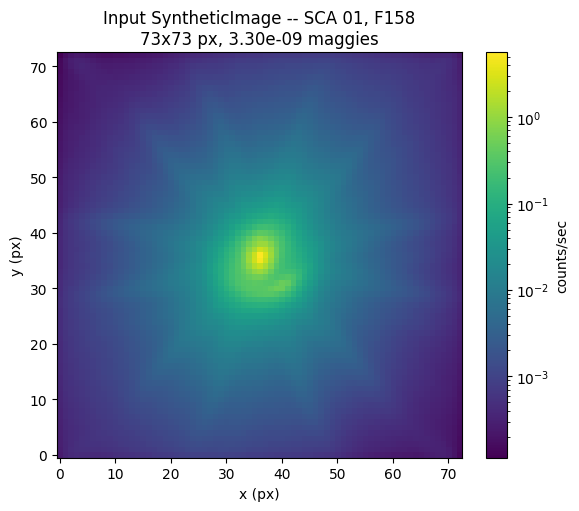

In [5]:
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
im = ax.imshow(synth.data, origin='lower', cmap='viridis',
               norm=LogNorm())
plt.colorbar(im, ax=ax, label='counts/sec')
ax.set_title(f'Input SyntheticImage -- SCA {SCA:02d}, {BAND}\n'
             f'{synth.data.shape[0]}x{synth.data.shape[1]} px, '
             f'{synth.get_maggies():.2e} maggies')
ax.set_xlabel('x (px)')
ax.set_ylabel('y (px)')
plt.show()

## Convert to Electrons and Define Source Sky Position

Convert the surface-brightness image to electron counts using the AB flux zeropoint:

    electrons = (pixel / sum_pixels) * maggies * abflux * exptime

The source's "true" sky position is defined as the boresight of the undithered pointing (dither step 0). For each subsequent dither, the WCS will project this sky position to a different pixel location on the detector.

In [6]:
# smooth negative/NaN pixels
smooth_data = np.asarray(mejiro_util.smooth_pixels(synth.data), dtype=np.float64)

# convert surface brightness -> electrons
synth_sum = np.sum(smooth_data, dtype=np.float64)
maggies = synth.get_maggies()
total_electrons = maggies * abflux * exptime
lens_electrons = (smooth_data / synth_sum) * total_electrons

print(f'Total electrons: {total_electrons:.2f}')
print(f'Tile min/max:    {lens_electrons.min():.3e} / {lens_electrons.max():.3e} e-')

# Find the source sky position that lands on the detector for all dithers
result = find_source_position(
    pointings=pointings,
    sca=SCA,
    band=BAND,
    tile_size=TILE_SIZE,
    ma_table_number=ma_table_number,
    date=date,
    pa_aper=PA_APER,
)
source_sky_galsim = result.sky_coord
source_sky_coord = SkyCoord(
    ra=source_sky_galsim.ra.deg * u.deg,
    dec=source_sky_galsim.dec.deg * u.deg,
)


Total electrons: 68123.06
Tile min/max:    6.999e-02 / 3.414e+03 e-


## Compute Pixel Positions for Each Dither

For each dithered pointing, build the romanisim WCS and project the source's sky position onto the detector. Because the SUB4 offsets are sub-pixel (< 0.1\"), the source lands at nearly the same pixel in every exposure, shifting by less than one pixel between dithers.

In [7]:
half_tile = TILE_SIZE // 2

pixel_positions = compute_pixel_positions(
    source_sky=source_sky_galsim,
    pointings=pointings,
    sca=SCA,
    band=BAND,
    tile_size=TILE_SIZE,
    ma_table_number=ma_table_number,
    date=date,
    pa_aper=PA_APER,
)


Step   Pixel X    Pixel Y    On detector?  
----------------------------------------
0      2043       2043       YES           
1      2044       2043       YES           
2      2043       2044       YES           
3      2043       2044       YES           


### Figure 2: Source Placement on Detector for Each Dither

Each panel shows the 4088x4088 detector footprint with the 73x73 source tile marked at its projected pixel position.

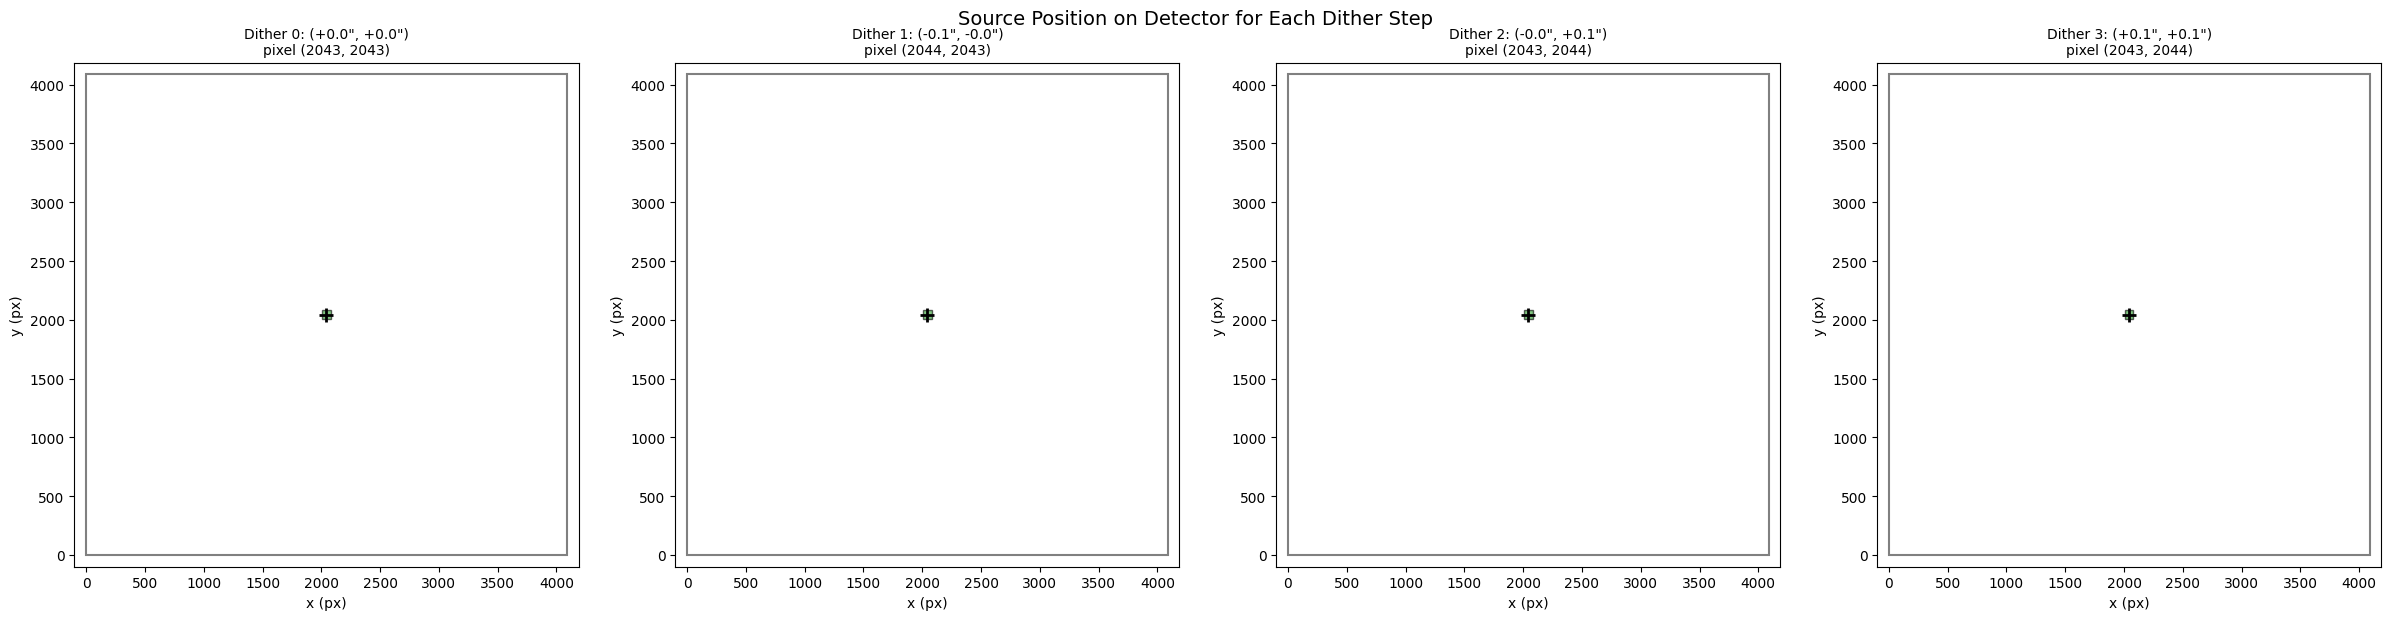

In [8]:
fig, axes = plot_source_placement(pixel_positions, DITHER_OFFSETS, TILE_SIZE)
plt.show()


## Simulate 4 Dithered L2 Exposures

For each dither position, we:
1. Place the source electrons at the computed pixel position in a 4088x4088 array
2. Apply Poisson noise to create integer counts
3. Run `romanisim.image.simulate()` with `extra_counts` to apply the full detector-effects chain (ramp sampling, IPC, read noise, dark current, ramp fitting)
4. Save the resulting L2 image as an ASDF file

Each exposure uses an independent RNG seed so noise realizations differ.

**Note:** Each simulation takes several minutes. Total runtime for 4 exposures: ~15-30 minutes.

In [9]:
FORCE_SIMULATE = True  # set True to re-run romanisim even if files exist

l2_files = [
    os.path.join(output_dir, f'mejiro_dither{i + 1:04d}_wfi{SCA:02d}_{BAND.lower()}_cal.asdf')
    for i in range(len(pointings))
]

if not FORCE_SIMULATE and all(os.path.exists(p) for p in l2_files):
    print('L2 files already exist — skipping simulation. Loading data arrays...')
    l2_data = []
    for path in l2_files:
        with asdf.open(path) as af:
            l2_data.append(np.array(af['roman']['data']))
        print(f'  Loaded: {path}')
    print(f'\nLoaded {len(l2_files)} existing L2 exposures from {output_dir}')

else:
    l2_data = []

    for i, dithered_coord in enumerate(pointings):
        cx, cy, on_det = pixel_positions[i]
        print(f'\n=== Dither {i}: offset ({DITHER_OFFSETS[i][0]:+.1f}\", {DITHER_OFFSETS[i][1]:+.1f}\"), '
              f'pixel ({cx}, {cy}) ===')

        # 1. build extra_counts array with source at computed position
        counts = np.zeros((4088, 4088), dtype=np.float64)
        # clip placement to detector bounds
        src_y0 = max(cy - half_tile, 0)
        src_y1 = min(cy + half_tile + 1, 4088)
        src_x0 = max(cx - half_tile, 0)
        src_x1 = min(cx + half_tile + 1, 4088)
        # src_x1/src_y1 can be negative when the source center is far off the
        # left/bottom edge (numpy would misinterpret as relative-from-end indices),
        # so only place the tile when it genuinely overlaps the detector.
        if src_y1 > src_y0 and src_x1 > src_x0:
            tile_y0 = src_y0 - (cy - half_tile)
            tile_y1 = TILE_SIZE - ((cy + half_tile + 1) - src_y1)
            tile_x0 = src_x0 - (cx - half_tile)
            tile_x1 = TILE_SIZE - ((cx + half_tile + 1) - src_x1)
            counts[src_y0:src_y1, src_x0:src_x1] = lens_electrons[tile_y0:tile_y1, tile_x0:tile_x1]

        # 2. Poisson noise
        rng_np = np.random.default_rng(seed + i)
        realized = rng_np.poisson(np.clip(counts, 0, None)).astype(np.int32)
        extra_counts = galsim.ImageI(realized)
        print(f'  extra_counts: {realized.sum():.0f} total e-')

        # 3. set up romanisim metadata
        meta = copy.deepcopy(parameters.default_parameters_dictionary)
        meta['instrument']['detector'] = f'WFI{SCA:02d}'
        meta['instrument']['optical_element'] = BAND
        meta['exposure']['ma_table_number'] = ma_table_number
        meta['exposure']['read_pattern'] = read_pattern
        meta['exposure']['start_time'] = Time(date)
        romanisim_wcs.fill_in_parameters(meta, dithered_coord, boresight=True, pa_aper=PA_APER)

        # empty source catalog
        source_catalog = table.Table({
            'ra':                np.array([], dtype='f8'),
            'dec':               np.array([], dtype='f8'),
            'type':              np.array([], dtype='U3'),
            'n':                 np.array([], dtype='f4'),
            'half_light_radius': np.array([], dtype='f4'),
            'pa':                np.array([], dtype='f4'),
            'ba':                np.array([], dtype='f4'),
            BAND:                np.array([], dtype='f4'),
        })

        # 4. run romanisim simulation
        rng_galsim = galsim.UniformDeviate(seed + i)
        print(f'  Running romanisim (level=2)...')
        im, extras = image.simulate(
            meta, source_catalog,
            usecrds=False,
            psftype='galsim',
            level=2,
            rng=rng_galsim,
            crparam=dict(),
            extra_counts=extra_counts,
        )
        print(f'  Done. Output shape: {im["data"].shape}')

        # 5. save as ASDF
        # MosaicPipeline's FluxStep requires meta.cal_step to exist; romanisim does
        # not populate it, so inject the node manually before saving.
        im['meta']['cal_step'] = {
            'assign_wcs':        'COMPLETE',
            'dark':              'COMPLETE',
            'dark_decay':        'COMPLETE',
            'dq_init':           'COMPLETE',
            'flat_field':        'COMPLETE',
            'flux':              'N/A',
            'linearity':         'COMPLETE',
            'outlier_detection': 'N/A',
            'photom':            'COMPLETE',
            'source_catalog':    'N/A',
            'ramp_fit':          'COMPLETE',
            'refpix':            'COMPLETE',
            'saturation':        'COMPLETE',
            'skymatch':          'N/A',
            'tweakreg':          'N/A',
            'wfi18_transient':   'N/A',
        }
        filepath = l2_files[i]
        af = asdf.AsdfFile()
        af.tree = {'roman': im}
        af.write_to(filepath)
        print(f'  Saved: {filepath}')

        l2_data.append(np.array(im['data']))

    print(f'\nAll {len(pointings)} L2 exposures saved to {output_dir}')


=== Dither 0: offset (+0.0", +0.0"), pixel (2043, 2043) ===


2026-06-28 16:58:46,383 WARNING romanisim: --usecrds is not set.  romanisim will not use reference files from CRDS.  The WCS may be incorrect and up-to-date calibration information will not be used.
2026-06-28 16:58:46,428 INFO romanisim: Simulating filter F158...


  extra_counts: 67663 total e-
  Running romanisim (level=2)...


2026-06-28 16:58:46,873 INFO romanisim: Creating PSF using galsim
2026-06-28 16:58:47,411 INFO romanisim: Creating PSF using galsim
2026-06-28 16:58:47,819 INFO romanisim: Creating PSF using galsim
2026-06-28 16:58:48,220 INFO romanisim: Creating PSF using galsim
2026-06-28 16:58:51,350 INFO romanisim: Adding 0 sources to image...
2026-06-28 16:58:51,353 WARNING romanisim: You requested fastpointsources, but the PSF and/or chromaticity are incompatible with this setting.  Disabling fastpointsources.
2026-06-28 16:58:51,412 INFO romanisim: Rendered 0 point sources in 0.0393 seconds
2026-06-28 16:58:51,413 INFO romanisim: Rendered 0 total sources in 0.059 seconds
2026-06-28 16:58:54,652 INFO romanisim: Apportioning electrons to resultants...
2026-06-28 17:04:07,816 INFO romanisim: Adding IPC...
2026-06-28 17:04:11,969 INFO romanisim: Adding read noise...
2026-06-28 17:04:17,057 INFO romanisim: Fitting ramps.
2026-06-28 17:04:41,391 INFO romanisim: Simulation complete.


  Done. Output shape: (4088, 4088)
  Saved: /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic_sub4/mejiro_dither0001_wfi01_f158_cal.asdf

=== Dither 1: offset (-0.1", -0.0"), pixel (2044, 2043) ===


...

  Done. Output shape: (4088, 4088)
  Saved: /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic_sub4/mejiro_dither0003_wfi01_f158_cal.asdf

=== Dither 3: offset (+0.1", +0.1"), pixel (2043, 2044) ===


2026-06-28 17:16:43,394 WARNING romanisim: --usecrds is not set.  romanisim will not use reference files from CRDS.  The WCS may be incorrect and up-to-date calibration information will not be used.
2026-06-28 17:16:43,402 INFO romanisim: Simulating filter F158...


  extra_counts: 68213 total e-
  Running romanisim (level=2)...


2026-06-28 17:16:43,885 INFO romanisim: Creating PSF using galsim
2026-06-28 17:16:44,366 INFO romanisim: Creating PSF using galsim
2026-06-28 17:16:44,861 INFO romanisim: Creating PSF using galsim
2026-06-28 17:16:45,334 INFO romanisim: Creating PSF using galsim
2026-06-28 17:16:48,550 INFO romanisim: Adding 0 sources to image...
2026-06-28 17:16:48,551 WARNING romanisim: You requested fastpointsources, but the PSF and/or chromaticity are incompatible with this setting.  Disabling fastpointsources.
2026-06-28 17:16:48,611 INFO romanisim: Rendered 0 point sources in 0.0405 seconds
2026-06-28 17:16:48,612 INFO romanisim: Rendered 0 total sources in 0.0603 seconds
2026-06-28 17:16:51,850 INFO romanisim: Apportioning electrons to resultants...
2026-06-28 17:22:07,633 INFO romanisim: Adding IPC...
2026-06-28 17:22:11,794 INFO romanisim: Adding read noise...
2026-06-28 17:22:16,774 INFO romanisim: Fitting ramps.
2026-06-28 17:22:40,718 INFO romanisim: Simulation complete.


  Done. Output shape: (4088, 4088)
  Saved: /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic_sub4/mejiro_dither0004_wfi01_f158_cal.asdf

All 4 L2 exposures saved to /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic_sub4


In [10]:
import glob as glob_mod
import asdf

# Edit cal_step entries here, then run this cell to update all L2 files in output_dir.
cal_step_overrides = {
    'assign_wcs':        'COMPLETE',
    'dark':              'COMPLETE',
    'dark_decay':        'COMPLETE',
    'dq_init':           'COMPLETE',
    'flat_field':        'COMPLETE',
    'flux':              'N/A',
    'linearity':         'COMPLETE',
    'outlier_detection': 'N/A',
    'photom':            'COMPLETE',
    'source_catalog':    'N/A',
    'ramp_fit':          'COMPLETE',
    'refpix':            'COMPLETE',
    'saturation':        'COMPLETE',
    'skymatch':          'N/A',
    'tweakreg':          'N/A',
    'wfi18_transient':   'N/A',
}

l2_files = sorted(glob_mod.glob(os.path.join(output_dir, '*_cal.asdf')))
print(f'Found {len(l2_files)} L2 files')
for path in l2_files:
    with asdf.open(path, mode='rw') as af:
        af['roman']['meta']['cal_step'].update(cal_step_overrides)
        af.write_to(path)
    print(f'  Updated: {path}')

Found 4 L2 files
  Updated: /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic_sub4/mejiro_dither0001_wfi01_f158_cal.asdf
  Updated: /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic_sub4/mejiro_dither0002_wfi01_f158_cal.asdf
  Updated: /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic_sub4/mejiro_dither0003_wfi01_f158_cal.asdf
  Updated: /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic_sub4/mejiro_dither0004_wfi01_f158_cal.asdf


### Figure 3: Four L2 Exposures (Full Detector)

Each panel shows the full 4088x4088 L2 image. With the sub-pixel SUB4 dithers, the source appears at essentially the same pixel position in each dither step (shifts are smaller than one pixel).

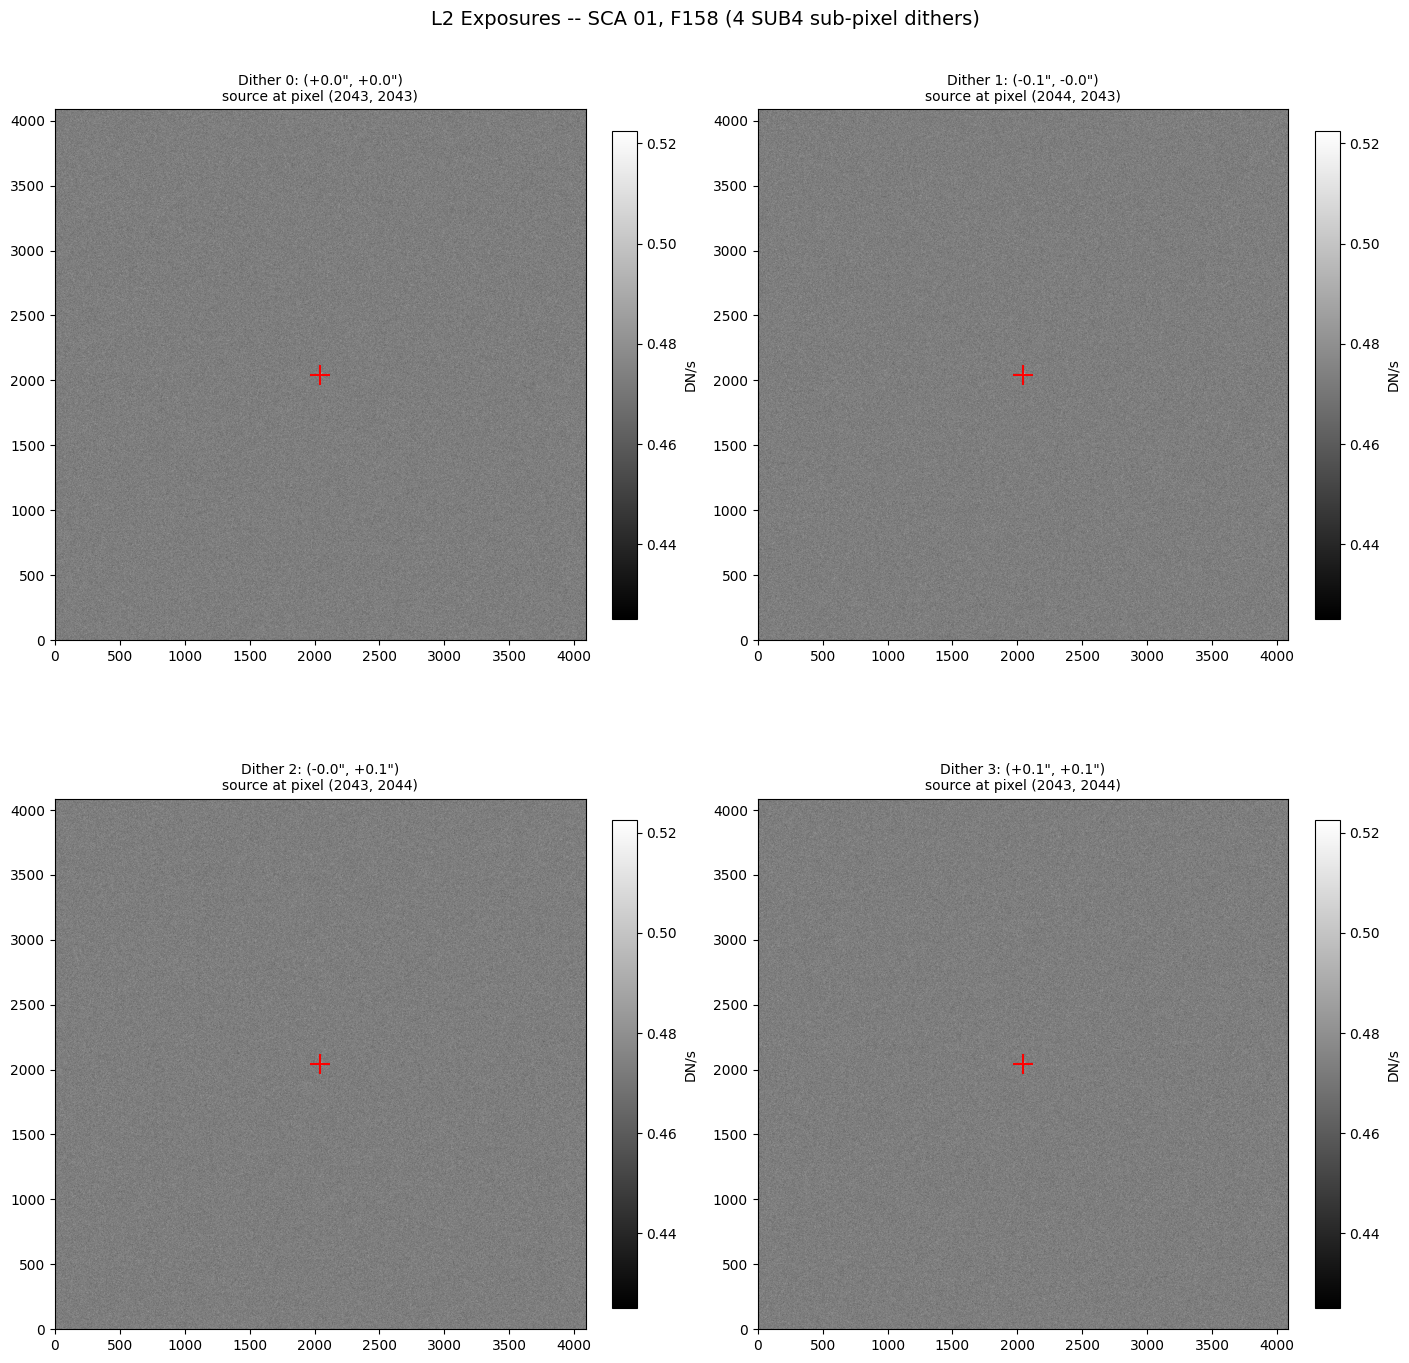

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14), constrained_layout=True)
fig.suptitle(f'L2 Exposures -- SCA {SCA:02d}, {BAND} (4 SUB4 sub-pixel dithers)', fontsize=14)

# common scale across all panels
all_vals = np.concatenate([d[np.isfinite(d)].flatten() for d in l2_data])
vmin_full = np.percentile(all_vals, 1)
vmax_full = np.percentile(all_vals, 99)

for i, ax in enumerate(axes.flat):
    cx, cy, _ = pixel_positions[i]
    x_off, y_off = DITHER_OFFSETS[i]

    im = ax.imshow(l2_data[i], origin='lower', cmap='gray', vmin=vmin_full, vmax=vmax_full)
    plt.colorbar(im, ax=ax, label='DN/s', fraction=0.046, pad=0.04)

    # mark source position
    ax.plot(cx, cy, 'r+', ms=15, mew=1.5)
    ax.set_title(f'Dither {i}: ({x_off:+.1f}", {y_off:+.1f}")\nsource at pixel ({cx}, {cy})',
                 fontsize=10)

plt.show()

### Figure 4: Zoomed Cutouts Around the Source

A 150x150 pixel cutout centered on the source in each dither. The source is the same object at the same sky position; with SUB4 the detector location barely changes (sub-pixel shifts), but each exposure has an independent noise realization and samples the PSF on a slightly offset sub-pixel grid.

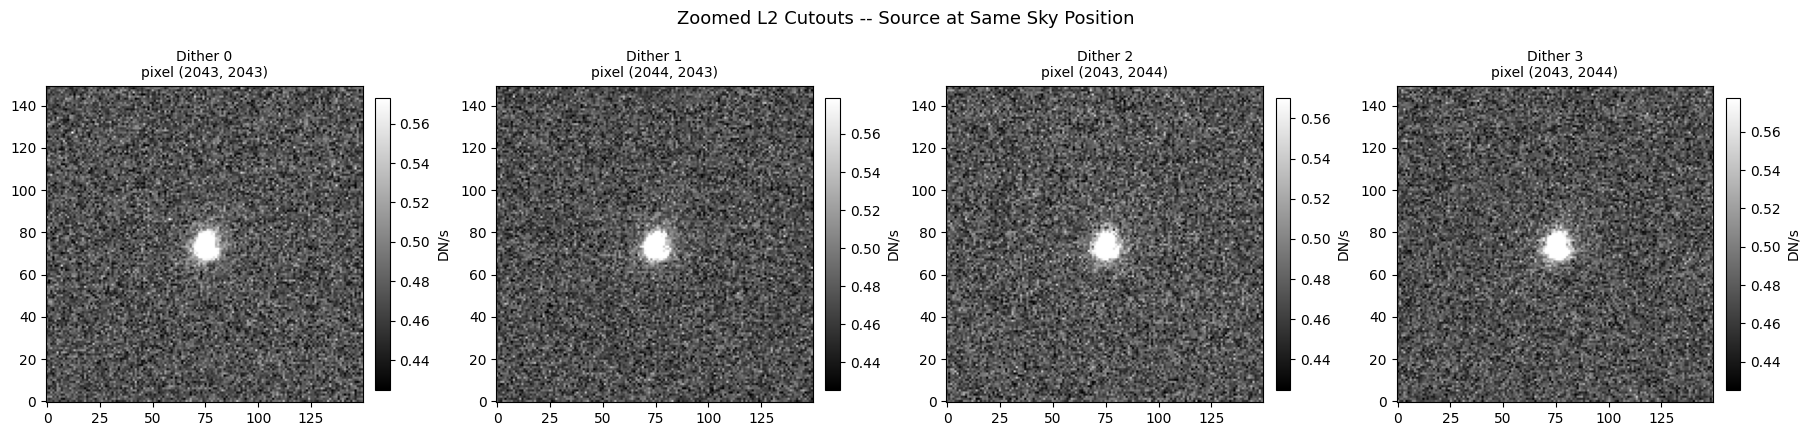

In [12]:
cutout_half = 75  # 150x150 pixel cutouts

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), constrained_layout=True)
fig.suptitle(f'Zoomed L2 Cutouts -- Source at Same Sky Position', fontsize=13)

for i, ax in enumerate(axes.flat):
    cx, cy, _ = pixel_positions[i]
    y0 = max(cy - cutout_half, 0)
    y1 = min(cy + cutout_half, 4088)
    x0 = max(cx - cutout_half, 0)
    x1 = min(cx + cutout_half, 4088)
    cutout = l2_data[i][y0:y1, x0:x1]

    vmin_c = np.nanpercentile(cutout, 1)
    vmax_c = np.nanpercentile(cutout, 99.5)
    im = ax.imshow(cutout, origin='lower', cmap='gray', vmin=vmin_c, vmax=vmax_c)
    plt.colorbar(im, ax=ax, label='DN/s', fraction=0.046, pad=0.04)
    ax.set_title(f'Dither {i}\npixel ({cx}, {cy})', fontsize=10)

plt.show()

## Create Association Files and Run MosaicPipeline (native + finer grid)

The romancal `MosaicPipeline` combines the L2 exposures into an L3 mosaic. We run it **twice** to compare output sampling:

- **Native grid** -- `pixel_scale_ratio = 1.0`, `pixfrac = 1.0` (standard ~0.11\"/px output)
- **Finer grid** -- `pixel_scale_ratio = 0.5`, `pixfrac = 0.7` (drizzle to ~0.055\"/px, exploiting the SUB4 sub-pixel sampling)

`pixel_scale_ratio` is the ratio of output to input pixel scale, so 0.5 produces output pixels half the linear size (4x as many pixels). With only 4 exposures, `pixfrac` is kept below 1.0 for the finer grid to limit holes and noise correlation -- tune both knobs in the run config below to experiment.

Each run needs its own JSON association (the product name sets the output filename). The pipeline applies: **Flux** (DN/s -> MJy/sr) and **Resample** (drizzle onto a common grid). Skymatch, outlier detection, and source catalog are skipped.

In [13]:
# Build one association per run; product_name sets the output filename.
def write_asn(product_name):
    asn_path = os.path.join(output_dir, f'{product_name}_asn.json')
    asn = asn_from_list.asn_from_list(
        [(f, 'science') for f in l2_files],
        product_name=product_name,
        with_exptype=True,
        target='',
    )
    _, serialized = asn.dump(format='json')
    with open(asn_path, 'w') as f:
        f.write(serialized)
    return asn_path

# Edit these to experiment with output sampling.
mosaic_runs = {
    'native': dict(product_name='mejiro_mosaic_native', pixel_scale_ratio=1.0, pixfrac=1.0),
    'fine':   dict(product_name='mejiro_mosaic_fine',   pixel_scale_ratio=0.5, pixfrac=0.7),
}
for run in mosaic_runs.values():
    run['asn_path'] = write_asn(run['product_name'])
    print(f"{run['product_name']:<22} ratio={run['pixel_scale_ratio']}  "
          f"pixfrac={run['pixfrac']}  ->  {run['asn_path']}")

mejiro_mosaic_native   ratio=1.0  pixfrac=1.0  ->  /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic_sub4/mejiro_mosaic_native_asn.json
mejiro_mosaic_fine     ratio=0.5  pixfrac=0.7  ->  /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic_sub4/mejiro_mosaic_fine_asn.json


In [14]:
# romanisim (usecrds=False) stores negative placeholder values for photometric conversion.
# The FluxStep multiplies data by conversion_megajanskys, so negative values produce an
# all-negative mosaic. Fix by taking the absolute value before running MosaicPipeline.
for path in l2_files:
    with asdf.open(path, mode='rw') as af:
        phot = af['roman']['meta']['photometry']
        phot['conversion_megajanskys'] = abs(float(phot['conversion_megajanskys']))
        phot['pixel_area']             = abs(float(phot['pixel_area']))
        af.write_to(path)
    print(f'  Patched photometry: {os.path.basename(path)}')

  Patched photometry: mejiro_dither0001_wfi01_f158_cal.asdf
  Patched photometry: mejiro_dither0002_wfi01_f158_cal.asdf
  Patched photometry: mejiro_dither0003_wfi01_f158_cal.asdf
  Patched photometry: mejiro_dither0004_wfi01_f158_cal.asdf


In [15]:
print('Running MosaicPipeline for native + finer grids...')
for label, run in mosaic_runs.items():
    print(f"\n=== {label}: {run['product_name']} "
          f"(pixel_scale_ratio={run['pixel_scale_ratio']}, pixfrac={run['pixfrac']}) ===")
    MosaicPipeline.call(
        run['asn_path'],
        save_results=True,
        output_dir=output_dir,
        resample_on_skycell=False,
        steps={
            'resample': {
                'pixel_scale_ratio': run['pixel_scale_ratio'],
                'pixfrac': run['pixfrac'],
            },
            'skymatch': {'skip': True},
            'outlier_detection': {'skip': True},
            'source_catalog': {'skip': True},
        },
    )
print('\nMosaicPipeline complete for both grids.')

2026-06-28 17:23:09,315 - py.warnings - WARNING - /nfsdata1/bwedig/.conda/envs/mejiro-v3/lib/python3.13/site-packages/roman_datamodels/datamodels/_utils.py:291: FilenameMismatchWarning: meta.filename: ? does not match filename: mejiro_dither0001_wfi01_f158_cal.asdf, updating the filename in memory!
  asdf_file = init if isinstance(init, asdf.AsdfFile) else _open_asdf(init, memmap=memmap, **kwargs)

2026-06-28 17:23:09,315 WARNING py.warnings: /nfsdata1/bwedig/.conda/envs/mejiro-v3/lib/python3.13/site-packages/roman_datamodels/datamodels/_utils.py:291: FilenameMismatchWarning: meta.filename: ? does not match filename: mejiro_dither0001_wfi01_f158_cal.asdf, updating the filename in memory!
  asdf_file = init if isinstance(init, asdf.AsdfFile) else _open_asdf(init, memmap=memmap, **kwargs)



Running MosaicPipeline for native + finer grids...

=== native: mejiro_mosaic_native (pixel_scale_ratio=1.0, pixfrac=1.0) ===


2026-06-28 17:23:10,079 - CRDS - INFO -  Fetching  /data/bwedig/STScI/crds_cache/mappings/roman/roman_wfi_matable_0004.rmap      690 bytes  (1 / 7 files) (0 / 12.2 K bytes)
2026-06-28 17:23:10,316 - CRDS - INFO -  Fetching  /data/bwedig/STScI/crds_cache/mappings/roman/roman_wfi_ipc_0003.rmap    3.3 K bytes  (2 / 7 files) (690 / 12.2 K bytes)
2026-06-28 17:23:10,534 - CRDS - INFO -  Fetching  /data/bwedig/STScI/crds_cache/mappings/roman/roman_wfi_etc_0002.rmap    2.3 K bytes  (3 / 7 files) (4.0 K / 12.2 K bytes)
2026-06-28 17:23:10,729 - CRDS - INFO -  Fetching  /data/bwedig/STScI/crds_cache/mappings/roman/roman_wfi_dustmap_0003.rmap      855 bytes  (4 / 7 files) (6.3 K / 12.2 K bytes)
2026-06-28 17:23:10,864 - CRDS - INFO -  Fetching  /data/bwedig/STScI/crds_cache/mappings/roman/roman_wfi_apcorr_0003.rmap    2.3 K bytes  (5 / 7 files) (7.1 K / 12.2 K bytes)
2026-06-28 17:23:11,078 - CRDS - INFO -  Fetching  /data/bwedig/STScI/crds_cache/mappings/roman/roman_wfi_0053.imap    2.4 K bytes

Maximum specified SIP approximation error: 5   - SIP degree: 1. Maximum residual: 0.0070717* Maximum residual, double sampled grid: 0.0070717* Final SIP degree: 1. Maximum residual: 0.0070717

2026-06-28 17:23:16,144 - stcal.resample.resample - INFO - Resampling science and variance data
2026-06-28 17:23:16,144 INFO stcal.resample.resample: Resampling science and variance data
2026-06-28 17:23:25,063 - stcal.resample.resample - INFO - Drizzling (4088, 4088) --> (5584, 5589)
2026-06-28 17:23:25,063 INFO stcal.resample.resample: Drizzling (4088, 4088) --> (5584, 5589)
2026-06-28 17:23:29,217 - stcal.resample.resample - INFO - Drizzling (4088, 4088) --> (5584, 5589)
2026-06-28 17:23:29,217 INFO stcal.resample.resample: Drizzling (4088, 4088) --> (5584, 5589)
2026-06-28 17:23:36,474 - stcal.resample.resample - INFO - Resampling science and variance data
2026-06-28 17:23:36,474 INFO stcal.resample.resample: Resampling science and variance data
2026-06-28 17:23:45,131 - stcal.resample.resample - INFO - Drizzling (4088, 4088) --> (5584, 5589)
2026-06-28 17:23:45,131 INFO stcal.resample.resample: Drizzling (4088, 4088) --> (5584, 5589)
2026-06-28 17:23:49,281 - stcal.resample.resamp


=== fine: mejiro_mosaic_fine (pixel_scale_ratio=0.5, pixfrac=0.7) ===


2026-06-28 17:24:41,407 INFO stpipe.step: Step MosaicPipeline running with args ('/nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic_sub4/mejiro_mosaic_fine_asn.json',).
2026-06-28 17:24:41,418 - stpipe.step - INFO - Step MosaicPipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir: /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/notebook_mosaic_sub4
  output_ext: .asdf
  output_use_model: False
  output_use_index: True
  save_results: True
  skip: False
  suffix: None
  search_output_file: True
  input_dir: ''
  update_version: False
  on_disk: False
  resample_on_skycell: False
  steps:
    flux:
      pre_hooks: []
      post_hooks: []
      output_file: None
      output_dir: None
      output_ext: .asdf
      output_use_model: False
      output_use_index: True
      save_results: False
      skip: False
      suffix: None
      search_output_file: True
      input_dir: ''
      update_version: False
    skymatch:
      pre_

Maximum specified SIP approximation error: 5   - SIP degree: 1. Maximum residual: 0.0070717* Maximum residual, double sampled grid: 0.0070717* Final SIP degree: 1. Maximum residual: 0.0070717

2026-06-28 17:24:45,226 - stcal.resample.resample - INFO - Resampling science and variance data
2026-06-28 17:24:45,226 INFO stcal.resample.resample: Resampling science and variance data
2026-06-28 17:25:01,263 - stcal.resample.resample - INFO - Drizzling (4088, 4088) --> (11167, 11179)
2026-06-28 17:25:01,263 INFO stcal.resample.resample: Drizzling (4088, 4088) --> (11167, 11179)
2026-06-28 17:25:07,670 - stcal.resample.resample - INFO - Drizzling (4088, 4088) --> (11167, 11179)
2026-06-28 17:25:07,670 INFO stcal.resample.resample: Drizzling (4088, 4088) --> (11167, 11179)
2026-06-28 17:25:22,815 - stcal.resample.resample - INFO - Resampling science and variance data
2026-06-28 17:25:22,815 INFO stcal.resample.resample: Resampling science and variance data
2026-06-28 17:25:38,097 - stcal.resample.resample - INFO - Drizzling (4088, 4088) --> (11167, 11179)
2026-06-28 17:25:38,097 INFO stcal.resample.resample: Drizzling (4088, 4088) --> (11167, 11179)
2026-06-28 17:25:44,513 - stcal.res


MosaicPipeline complete for both grids.


## Inspect the L3 Mosaics

Open both coadds and report their shapes and the realized output/input pixel-scale ratio. The finer grid should have ~2x the linear dimension (4x the pixels) of the native grid.

In [16]:
mosaics = {}
for label, run in mosaic_runs.items():
    path = os.path.join(output_dir, f"{run['product_name']}_coadd.asdf")
    m = rdm.open(path)
    mosaics[label] = m
    data = np.asarray(m.data, dtype=float)
    ratio = float(m.meta.resample.pixel_scale_ratio)
    print(f"{label:<8} {os.path.basename(path)}")
    print(f"         shape {data.shape}  dtype {data.dtype}")
    print(f"         pixel_scale_ratio (out/in) = {ratio:.3f}")
    print(f"         data range {np.nanmin(data):.4e} .. {np.nanmax(data):.4e} MJy/sr\n")

native   mejiro_mosaic_native_coadd.asdf
         shape (5584, 5589)  dtype float64
         pixel_scale_ratio (out/in) = 1.000
         data range 3.0589e-01 .. 2.0584e+00 MJy/sr

fine     mejiro_mosaic_fine_coadd.asdf
         shape (11167, 11179)  dtype float64
         pixel_scale_ratio (out/in) = 0.500
         data range 3.0025e-01 .. 2.4092e+00 MJy/sr



### Figure 5: L3 Mosaics -- Native vs Finer Grid

The two co-added mosaics in MJy/sr. They cover the same sky area; the finer-grid product simply samples it on a denser pixel grid.

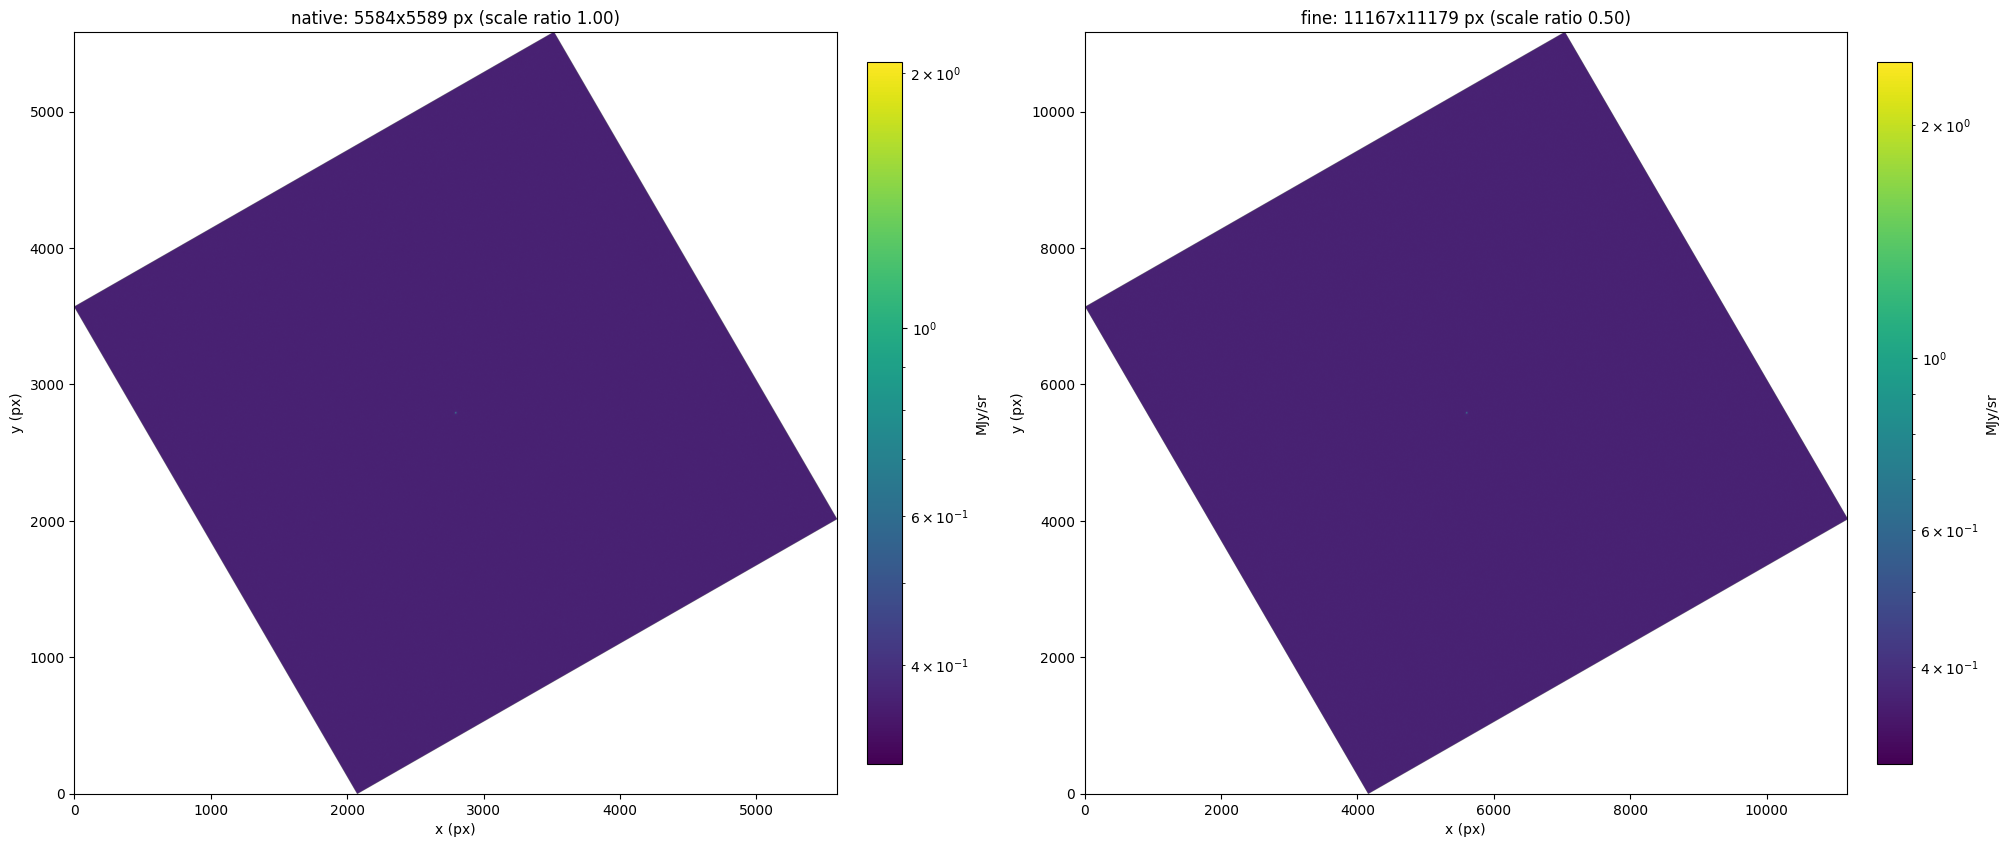

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), constrained_layout=True)
for ax, label in zip(axes, ['native', 'fine']):
    data = np.asarray(mosaics[label].data, dtype=float)
    im = ax.imshow(data, origin='lower', norm=LogNorm(), cmap='viridis')
    plt.colorbar(im, ax=ax, label='MJy/sr', fraction=0.046, pad=0.04)
    ratio = float(mosaics[label].meta.resample.pixel_scale_ratio)
    ax.set_title(f'{label}: {data.shape[0]}x{data.shape[1]} px (scale ratio {ratio:.2f})', fontsize=12)
    ax.set_xlabel('x (px)')
    ax.set_ylabel('y (px)')
plt.show()

### Figure 6: Context and Weight Maps (finer grid)

With only 4 exposures, the finer grid is where coverage uniformity matters most:
- **Context**: which input images contributed to each output pixel
- **Weight**: relative coverage -- look for holes or low-weight pixels introduced by the aggressive `pixfrac`

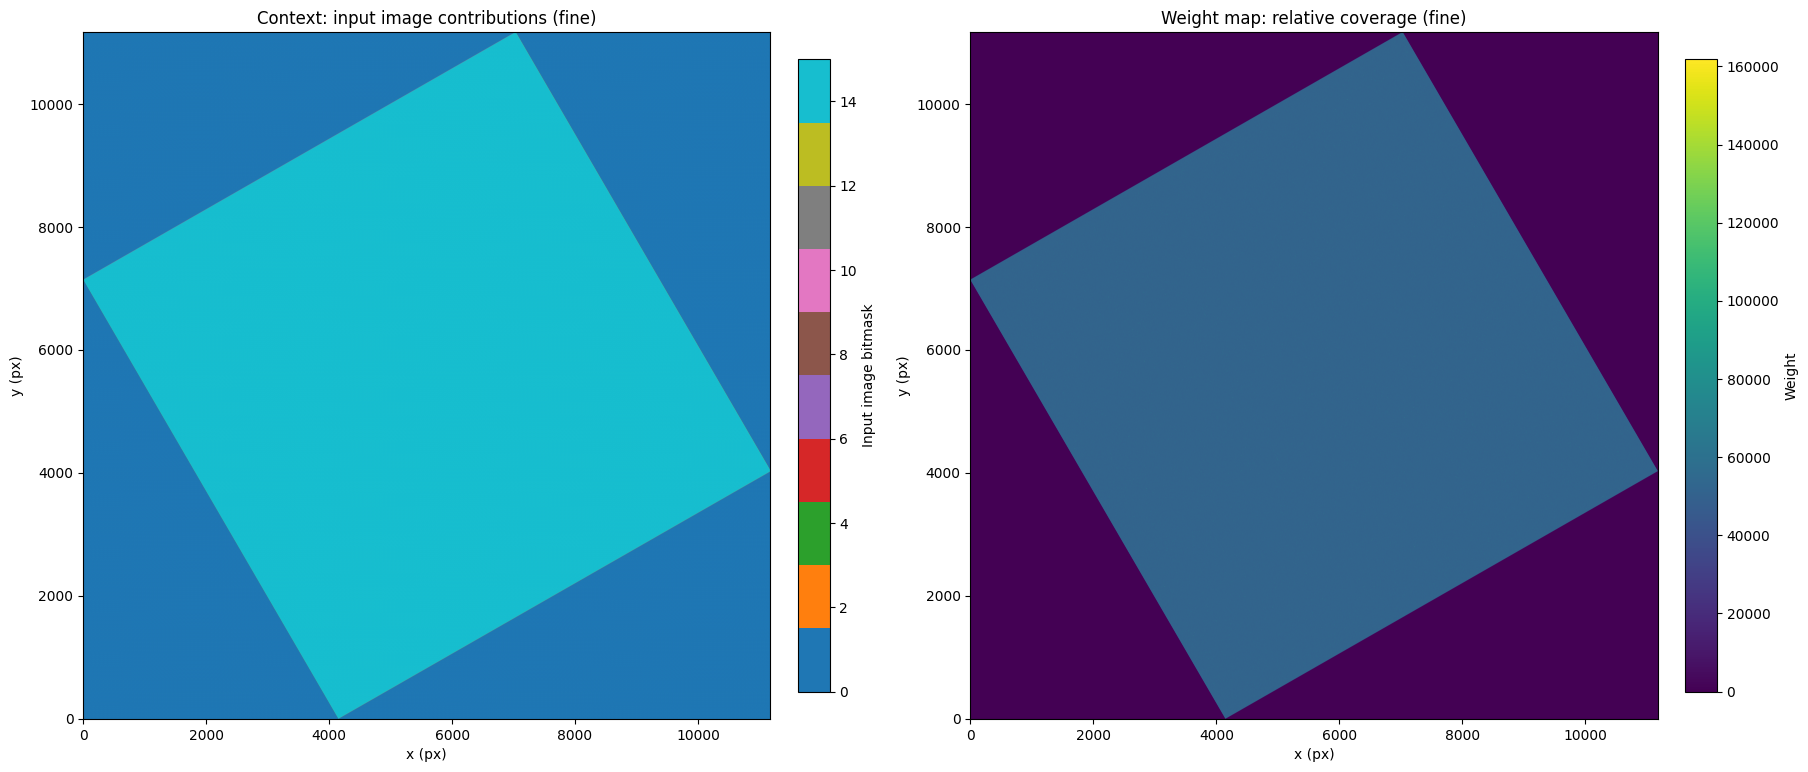

In [18]:
mos_file = mosaics['fine']
fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

# context map
ctx = np.array(mos_file.context[0], dtype=float)
im0 = axes[0].imshow(ctx, origin='lower', cmap='tab10')
plt.colorbar(im0, ax=axes[0], label='Input image bitmask', fraction=0.046, pad=0.04)
axes[0].set_title('Context: input image contributions (fine)', fontsize=12)
axes[0].set_xlabel('x (px)')
axes[0].set_ylabel('y (px)')

# weight map
wt = np.array(mos_file.weight, dtype=float)
im1 = axes[1].imshow(wt, origin='lower', cmap='viridis')
plt.colorbar(im1, ax=axes[1], label='Weight', fraction=0.046, pad=0.04)
axes[1].set_title('Weight map: relative coverage (fine)', fontsize=12)
axes[1].set_xlabel('x (px)')
axes[1].set_ylabel('y (px)')

plt.show()

### Figure 7: Source Cutout -- Input vs Native L3 vs Finer L3

Cutouts of matched physical size centered on the source's sky position in each product. The finer-grid mosaic spreads the source over ~2x as many pixels per axis, which can reveal structure blurred together at native sampling -- at the cost of higher per-pixel noise. This is where the SUB4 sub-pixel dithering pays off (or doesn't, given only 4 exposures): compare the two L3 panels.

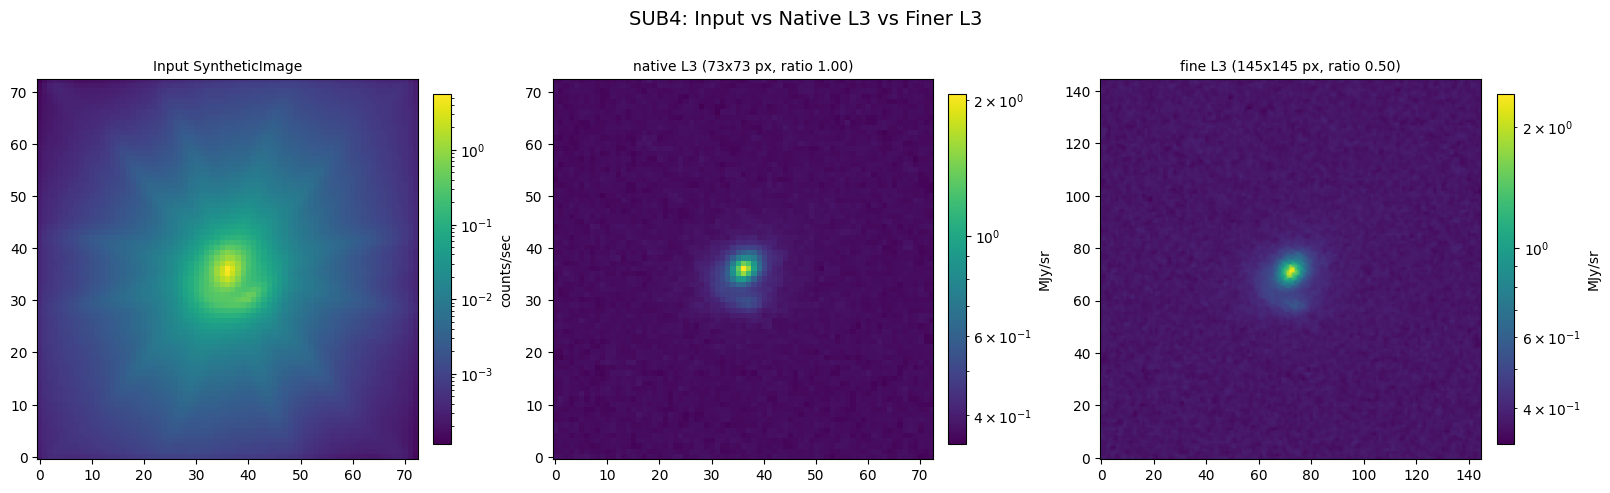

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
fig.suptitle('SUB4: Input vs Native L3 vs Finer L3', fontsize=14)

# input SyntheticImage
im0 = axes[0].imshow(synth.data, origin='lower', cmap='viridis', norm=LogNorm())
plt.colorbar(im0, ax=axes[0], label='counts/sec', fraction=0.046, pad=0.04)
axes[0].set_title('Input SyntheticImage', fontsize=10)

# native and finer L3 cutouts, matched to the same physical size
for ax, label in zip(axes[1:], ['native', 'fine']):
    m = mosaics[label]
    data = np.asarray(m.data, dtype=float)
    ratio = float(m.meta.resample.pixel_scale_ratio)
    half = int(round(half_tile / ratio))  # finer grid -> more output pixels per arcsec
    mx, my = m.meta.wcs.world_to_pixel(source_sky_coord)
    mcx, mcy = int(round(float(mx))), int(round(float(my)))
    cut = data[max(mcy - half, 0):min(mcy + half + 1, data.shape[0]),
               max(mcx - half, 0):min(mcx + half + 1, data.shape[1])]
    # orient to match the input image (same transform as the BOXGAP4 notebook)
    cut_disp = np.flip(cut.T, axis=(0, 1))
    im = ax.imshow(cut_disp, origin='lower', cmap='viridis', norm=LogNorm())
    plt.colorbar(im, ax=ax, label='MJy/sr', fraction=0.046, pad=0.04)
    ax.set_title(f'{label} L3 ({cut.shape[0]}x{cut.shape[1]} px, ratio {ratio:.2f})', fontsize=10)

plt.show()